In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter


import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

In [2]:
# from google.colab import files

# uploaded = files.upload

In [3]:
class EEGNet(nn.Module):
    def __init__(self, num_classes=7, num_channels=24, input_samples=1500, dropout_rate=0.25, kernel_length=64, F1=8, D=2, F2=16):
        super(EEGNet, self).__init__()

        self.num_classes = num_classes

        self.firstConv = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1,kernel_length), padding=(0, kernel_length//2), bias=False),
            nn.BatchNorm2d(F1)
        )

        self.depthwiseConv = nn.Sequential(
            nn.Conv2d(F1, F1*D, kernel_size=(num_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1,4)),
            nn.Dropout(p=dropout_rate)
        )

        self.separableConv = nn.Sequential(
            nn.Conv2d(F1*D, F2, kernel_size=(1,16), padding=(0,8), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1,8)),
            nn.Dropout(p=dropout_rate)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, num_channels, input_samples)
            x = self.firstConv(dummy)
            x = self.depthwiseConv(x)
            x = self.separableConv(x)
            # print (x.shape)
            flattened = x.shape[1] * x.shape[2] * x.shape[3]


        self.classify = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened, num_classes)
        )

    def forward(self, x):
        x = self.firstConv(x)
        x = self.depthwiseConv(x)
        x = self.separableConv(x)
        x = self.classify(x)
        return x

In [4]:
# Train and evaluate
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for X,y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

def evaluate(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in test_loader:
            X,y = X.to(device), y.to(device)
            out = model(X)
            pred = out.argmax(dim=1)  # FIXED: Changed from argmin to argmax

            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / total

def evaluateFinal(model, test_loader, device):
    model.eval()
    correct, total = 0, 0

    actual = torch.tensor([])
    predicted = torch.tensor([])
    with torch.no_grad():
        for X, y in test_loader:
            X,y = X.to(device), y.to(device)
            out = model(X)
            pred = out.argmax(dim=1)  # FIXED: Changed from argmin to argmax

            correct += (pred == y).sum().item()
            total += y.size(0)

            actual = torch.cat((actual, y.cpu()), dim=0)
            predicted = torch.cat((predicted, pred.cpu()), dim=0)

        print(np.unique(predicted.numpy(), return_counts=True))

        cm = confusion_matrix(actual.numpy(), predicted.numpy())
        ConfusionMatrixDisplay(cm).plot()

    print(f"The accuracy for the test is {(correct / total)*100:.2f}%")

    return correct / total

In [5]:
# DataLoader with proper data type handling

class BCIDataset(Dataset):
    def __init__(self, X, y):
        # Ensure proper data types to avoid kernel crashes
        # X should be float32, y should be int64 (long)
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

1. Load the data

The first thing we need to do is to load the data from our input file and check its content to make suure that we are aactually loading complete data

In [6]:
"""
Alternative data loading that might fix the label mismatch issue
"""

def load_data_method_1(file_path):
    """
    Original method - iterates gesture_type then row
    """
    mat_file = scipy.io.loadmat(file_path)
    cell_array = mat_file["combinedCell"]
    # print(mat_file.keys())

    X, Y = [], []
    num_classes = cell_array.shape[1]
    num_training_ex = cell_array.shape[0]

    possibleGestures = [1,2,3,6,7,8,9]

    print("num_classes", num_classes)
    print("num_training_ex", num_training_ex)

    for gesture_type in range(num_classes):
        for row_idx in range(num_training_ex):
            cell = cell_array[row_idx, gesture_type]
            cell = np.array(cell)
            # X.append(cell)
            X.append(cell.astype(np.float32))
            Y.append(gesture_type)

    return np.array(X), np.array(Y)


def load_data_method_2(file_path):
    """
    Alternative method - maybe cell_array columns are inverted?
    """
    mat_file = scipy.io.loadmat(file_path)
    cell_array = mat_file['processed_data']

    X, Y = [], []
    num_classes = cell_array.shape[1]
    num_training_ex = cell_array.shape[0]

    # Try inverted labels: if column 0 is actually gesture 6, etc.
    for gesture_type in range(num_classes):
        for row_idx in range(num_training_ex):
            cell = cell_array[row_idx, gesture_type]
            cell = np.array(cell)
            X.append(cell.astype(np.float32))
            # INVERTED: last column = label 0, first column = label 6
            Y.append(num_classes - 1 - gesture_type)

    return np.array(X), np.array(Y)


def load_data_method_3(file_path):
    """
    Check if we need to swap rows and columns
    """
    mat_file = scipy.io.loadmat(file_path)
    cell_array = mat_file['processed_data']

    print(f"Cell array shape: {cell_array.shape}")
    print(f"Trying transposed interpretation...")

    # Maybe shape is actually (7, 28) not (28, 7)?
    X, Y = [], []

    for row_idx in range(cell_array.shape[0]):
        for gesture_type in range(cell_array.shape[1]):
            cell = cell_array[row_idx, gesture_type]
            cell = np.array(cell)
            X.append(cell.astype(np.float32))
            Y.append(gesture_type)

    return np.array(X), np.array(Y)

In [7]:
# Load the .mat file
file_path = "E:/Chris/EMG/Data/put_emg_model_data.mat"
X, Y = load_data_method_1(file_path)

num_classes 7
num_training_ex 1760


In [8]:
print(X.shape)
print(Y.shape)

(12320, 1500, 24)
(12320,)


In [10]:
# X, Y = [],[]

# for gesture_type in range(num_classes):
#     for row_idx in range(num_training_ex):

#         # we get the gesture and save it as a np array
#         cell = cell_array[row_idx, gesture_type]
#         cell = np.array(cell)

#         if (gesture_type ==2 and row_idx == 7):
#           print(cell[13])

#         #  we make sure our EV reading are stores as float32
#         X.append(cell)
#         # X.append(np.array(cell, dtype=np.float32))
#         # X.append(cell.astype(np.float32))


#         # # # we create labels for our data
#         Y.append(gesture_type)



# # Convert list to NumPy arrays
# X = np.array(X)
# Y = np.array(Y)

In [11]:
print(np.unique(Y, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6]), array([1760, 1760, 1760, 1760, 1760, 1760, 1760], dtype=int64))


In [12]:
# checking for unique values
print(f"X shape: {X.shape}")
print(f"y shape: {Y.shape}")
print(f"Those are the unique label values {np.unique(Y)}")

X shape: (12320, 1500, 24)
y shape: (12320,)
Those are the unique label values [0 1 2 3 4 5 6]


2. Prepare the data for training

Here we need to get the data in a format that works with our model.
Our model takes on 4-Dimensional input so we need to add a new dimension to our training example.

We then need to split the data in training and testing set. We'll do 20% for testing and 80% for training

Finally, we need to pass the data to our pre-define data loaders so that it can be used to train the model

In [13]:
# adding an extra dimention to our training example
X = X[:, np.newaxis, :, :]
X = np.transpose(X, (0, 1, 3, 2))

Y= Y.squeeze()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42
)

In [15]:
print(np.unique(y_train, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6]), array([1408, 1408, 1408, 1408, 1408, 1408, 1408], dtype=int64))


In [16]:
print(f"X shape: {X.shape}")
print(f"y shape: {Y.shape}")

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# print(Counter(y_train))

X shape: (12320, 1, 24, 1500)
y shape: (12320,)
X_train shape: (9856, 1, 24, 1500)
y_train shape: (9856,)
X_test shape: (2464, 1, 24, 1500)
y_test shape: (2464,)


In [21]:
# print(y_test[0:100])
print(y_test)

setk ={}
for i in y_test:
    if i in setk :
        setk[i] +=1
    else:
        setk[i] = 1


print(setk)

[0 1 0 ... 6 5 3]
{0: 352, 1: 352, 5: 352, 2: 352, 6: 352, 3: 352, 4: 352}


In [ ]:
train_ds = BCIDataset(X_train, y_train)

val_ds = BCIDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

In [ ]:
print("Unique labels in dataset:", torch.unique(train_ds.y))

Unique labels in dataset: tensor([0, 1, 2, 3, 4, 5, 6])


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


3. Moodel and Traing

Now we can create the model and start training

In [ ]:
model = EEGNet(num_classes= 7, num_channels=24, input_samples=1500, dropout_rate=0.1)
# model = model.float()

In [ ]:
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

In [25]:
mx_acc = 0
for epoch in range(10):
    loss = train(model, train_loader, criterion, optimizer, device)
    acc = evaluate(model, val_loader, device)
    if acc > mx_acc:
        mx_acc = acc
    print(f"Epoch {epoch}: Loss= {loss:.4f}, Accuracy: {acc*100:.2f}%, Max Acc: {mx_acc*100:.2f}")

Epoch 0: Loss= 0.6523, Accuracy: 74.88%, Max Acc: 74.88
Epoch 1: Loss= 0.6335, Accuracy: 77.27%, Max Acc: 77.27
Epoch 2: Loss= 0.6468, Accuracy: 73.54%, Max Acc: 77.27
Epoch 3: Loss= 0.6261, Accuracy: 76.22%, Max Acc: 77.27
Epoch 4: Loss= 0.5993, Accuracy: 78.33%, Max Acc: 78.33
Epoch 5: Loss= 0.6072, Accuracy: 78.00%, Max Acc: 78.33
Epoch 6: Loss= 0.5726, Accuracy: 77.88%, Max Acc: 78.33
Epoch 7: Loss= 0.5904, Accuracy: 78.86%, Max Acc: 78.86
Epoch 8: Loss= 0.5778, Accuracy: 79.83%, Max Acc: 79.83
Epoch 9: Loss= 0.5597, Accuracy: 76.26%, Max Acc: 79.83


(array([0., 1., 2., 3., 4., 5., 6.], dtype=float32), array([305, 352, 368, 689, 243, 204, 303], dtype=int64))
The accuracy for the test is 76.26%


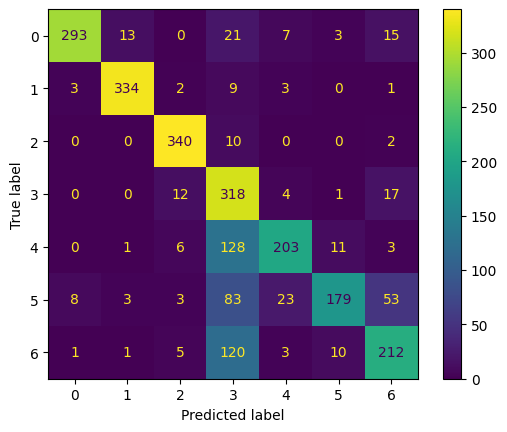

In [27]:
acc = evaluateFinal(model, val_loader, device)